# LeetCode #702: Search in a Sorted Array of Unknown Size

https://leetcode.com/problems/search-in-a-sorted-array-of-unknown-size/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan via API)** | $O(n)$ | $O(1)$ |
| **Optimal: Exponential Search + Binary Search ★** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan via API)
Call `reader.get(i)` for i=0,1,2,… until finding the target or hitting INT_MAX. $O(n)$ API calls.

### Optimal: Exponential Search + Binary Search ★
First double the search window (1→2→4→8→…) until `reader.get(hi) >= target` — this finds an upper bound in $O(\log n)$ API calls. Then binary search within `[lo, hi]` in another $O(\log n)$ calls. Total: $O(\log n)$ with $O(1)$ space.

**Constraints:**
* The array is sorted in ascending order
* -10^4 <= target <= 10^4
* The answer is guaranteed to exist
* reader.get(i) returns INT_MAX for out-of-bounds indices


## Solutions

### C#

In [ ]:
// ArrayReader is the API interface provided by the problem
public int Search(ArrayReader reader, int target) {
    // Phase 1: Exponential expansion to find upper bound
    int lo = 0, hi = 1;
    while (reader.get(hi) < target) { lo = hi; hi *= 2; }
    // Phase 2: Binary search within the bracketed range
    while (lo <= hi) {
        int mid = lo + (hi - lo) / 2;
        int val = reader.get(mid);
        if (val == target) return mid;
        if (val < target) lo = mid + 1;
        else hi = mid - 1;
    }
    return -1;
}


### Python

In [ ]:
def search(self, reader, target: int) -> int:
    # Phase 1: Exponential expansion to find upper bound
    lo, hi = 0, 1
    while reader.get(hi) < target:
        lo, hi = hi, hi * 2
    # Phase 2: Binary search within the bracketed range
    while lo <= hi:
        mid = lo + (hi - lo) // 2
        val = reader.get(mid)
        if val == target:
            return mid
        if val < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1


### Go

In [ ]:
func search(reader ArrayReader, target int) int {
    // Phase 1: Exponential expansion to find upper bound
    lo, hi := 0, 1
    for reader.get(hi) < target {
        lo, hi = hi, hi*2
    }
    // Phase 2: Binary search within the bracketed range
    for lo <= hi {
        mid := lo + (hi-lo)/2
        val := reader.get(mid)
        if val == target { return mid }
        if val < target { lo = mid + 1 } else { hi = mid - 1 }
    }
    return -1
}


### Rust

In [ ]:
pub fn search(reader: &ArrayReader, target: i32) -> i32 {
    // Phase 1: Exponential expansion to find upper bound
    let (mut lo, mut hi) = (0i32, 1i32);
    while reader.get(hi) < target { lo = hi; hi *= 2; }
    // Phase 2: Binary search within the bracketed range
    while lo <= hi {
        let mid = lo + (hi - lo) / 2;
        let val = reader.get(mid);
        if val == target { return mid; }
        if val < target { lo = mid + 1; } else { hi = mid - 1; }
    }
    -1
}


## Example Scenarios

**1. Common Case**
**Input:** array = [-1, 0, 3, 5, 9, 12], target = 9
Expansion: hi=1(0)<9→lo=1,hi=2; get(2)=3<9→lo=2,hi=4; get(4)=9≥9 → stop. Binary search [2,4]: mid=3(5)<9→lo=4; mid=4(9)=target→return 4.

**2. Slightly Complex**
**Input:** array = [-1, 0, 3, 5, 9, 12], target = 2
Expansion: hi=1(0)<2→lo=1,hi=2; get(2)=3≥2 → stop [1,2]. Binary search: mid=1(0)<2→lo=2; mid=2(3)>2→hi=1; lo>hi → return -1. Target absent.

**3. Edge Case: Time Factor**
**Input:** array length n=10^4, target at last index
Expansion doubles hi until hi≥n: $\lceil \log_2(10^4) \rceil = 14$ doubling steps. Binary search in range [hi/2, hi]: another 14 steps. Total $\approx 28$ API calls vs $O(n)$ linear.

**4. Edge Case: Space Factor**
**Input:** array = [1], target = 1
Expansion: get(1)=INT_MAX≥1 → stop immediately. Binary search [0,1]: mid=0(1)=target→return 0. $O(1)$ space: only lo, hi, mid, val.

**5. Almost-Impossible but Plausible**
**Input:** array = [10000], target = 10000 (max value, single element)
Expansion: lo=0,hi=1; get(1)=INT_MAX≥10000 → stop. Binary [0,1]: mid=0, get(0)=10000=target→return 0. Edge: get(1)=INT_MAX is correct sentinel behavior — the algorithm treats any value ≥ target as a valid upper bound.


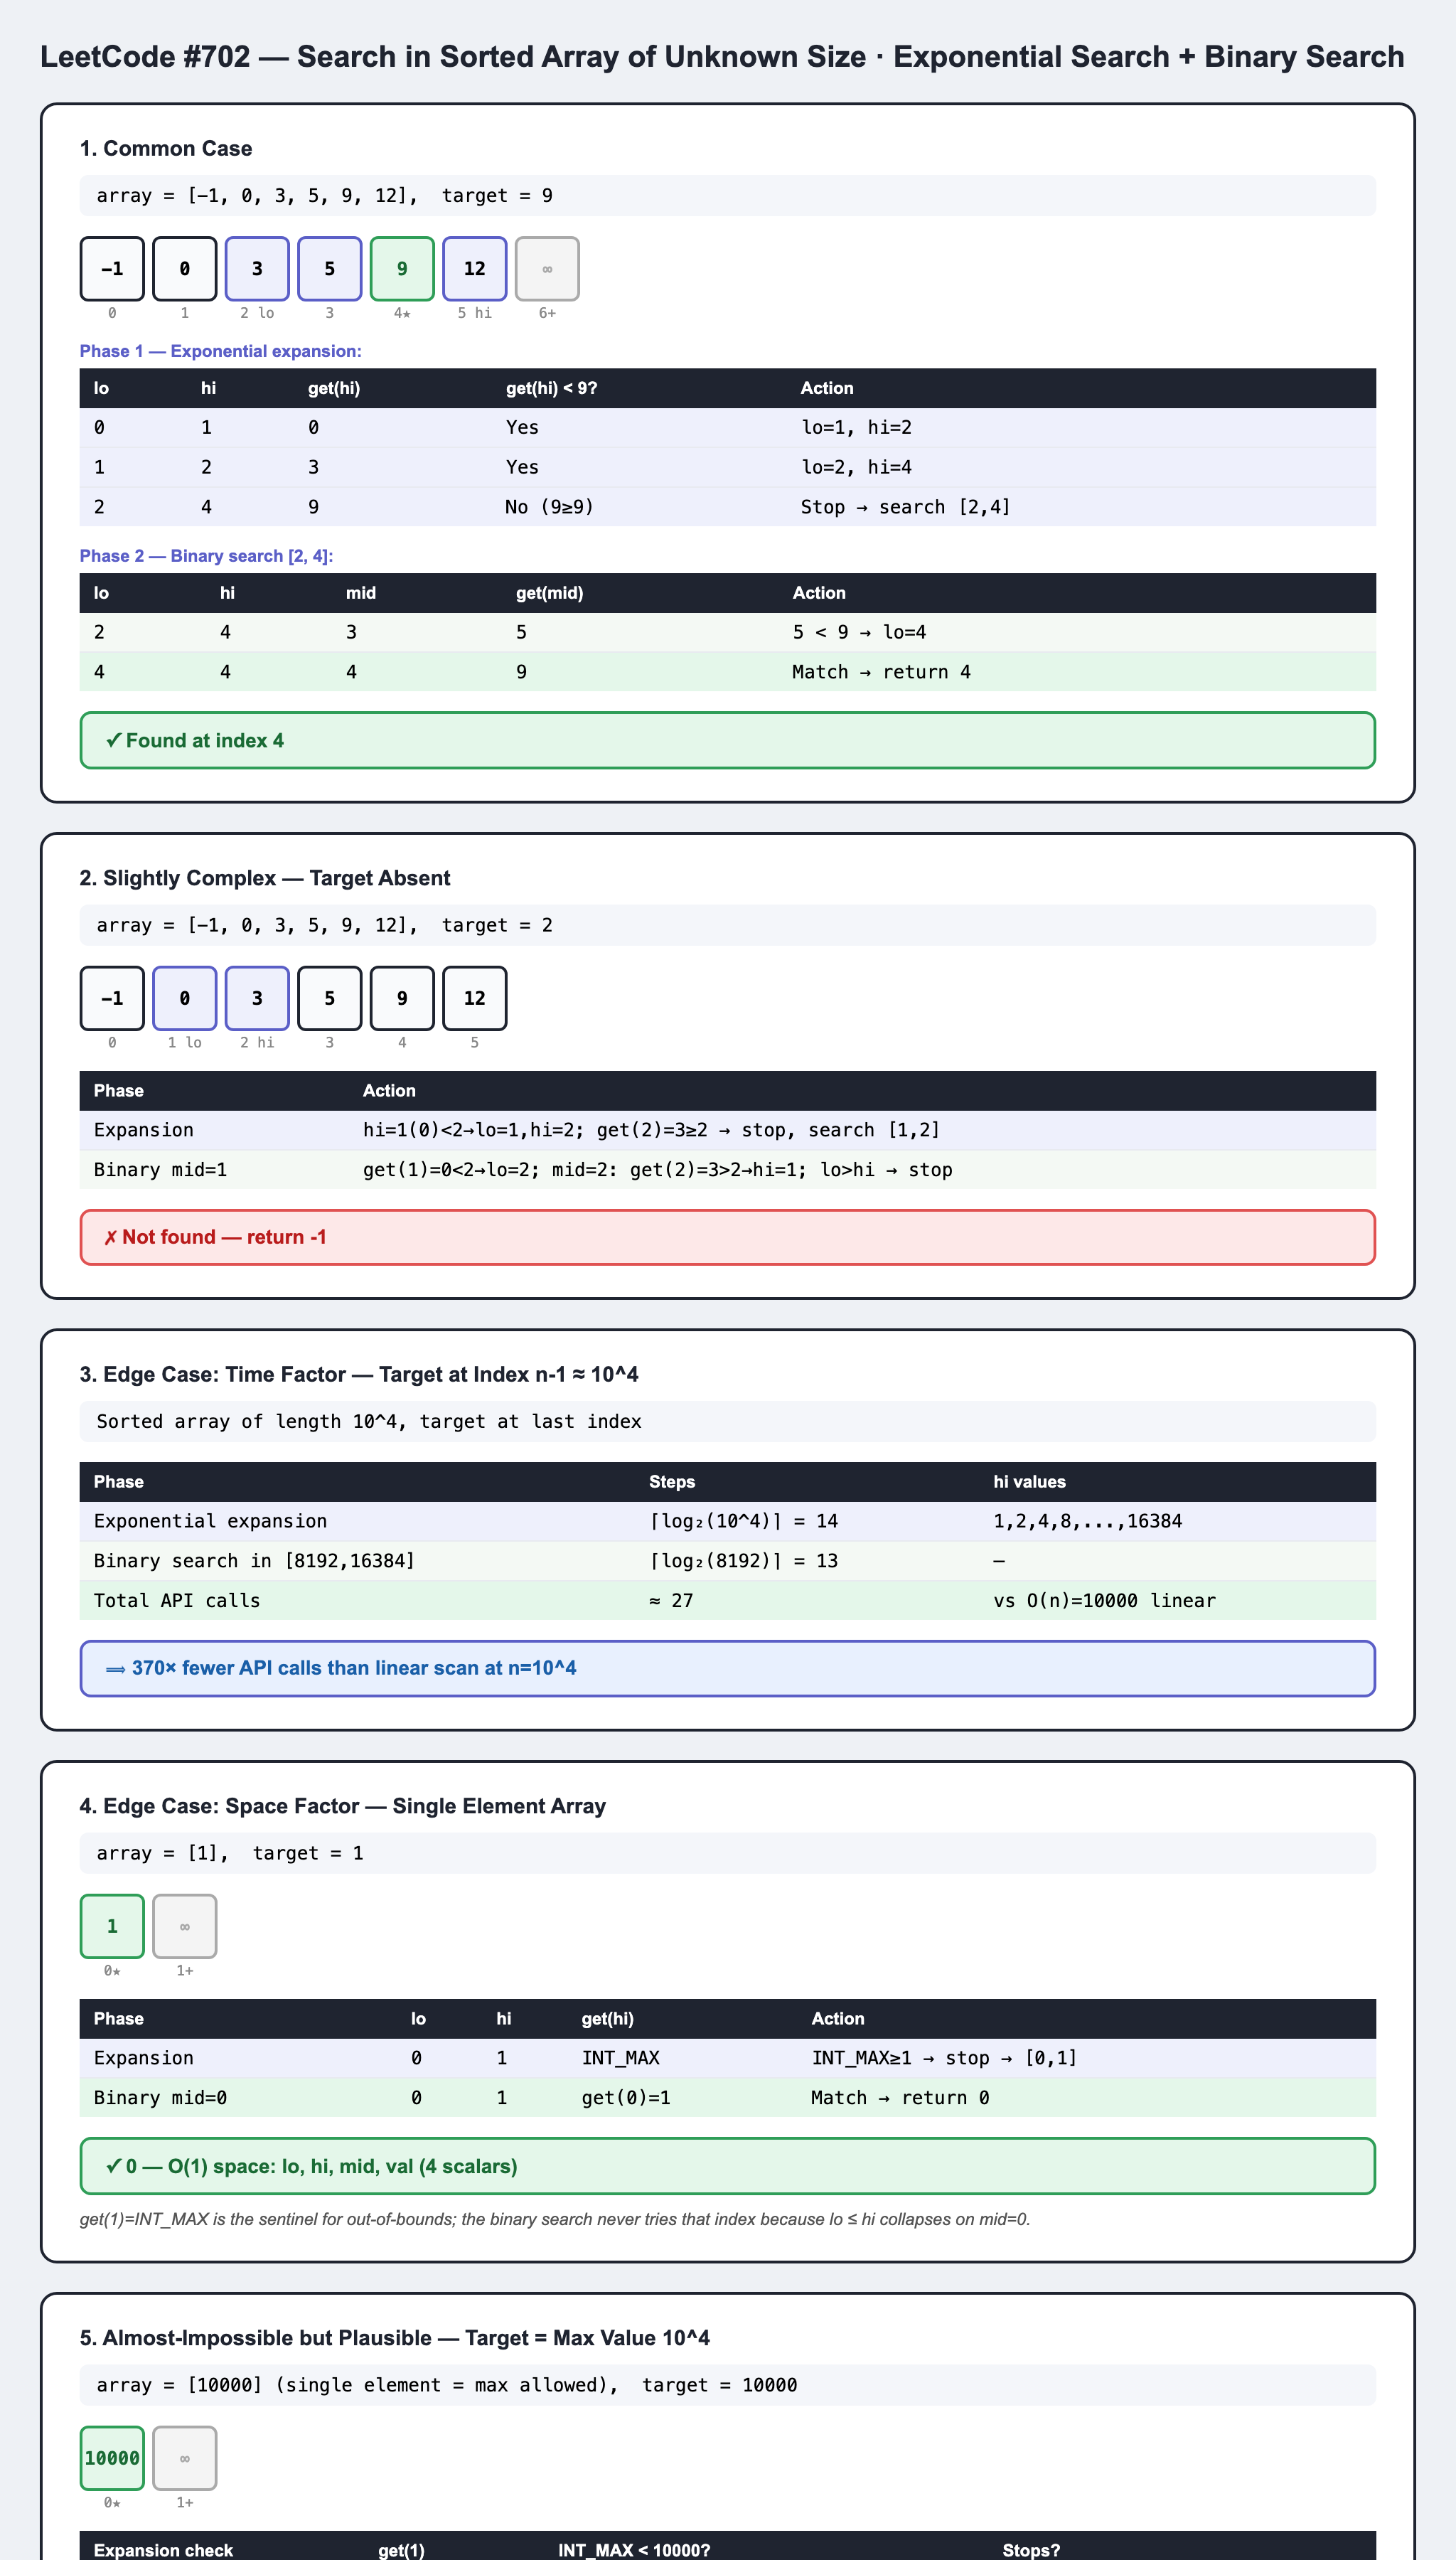